In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

In [26]:
board = cv2.imread('test_images/chessboard.png')
if board is None:
    cap = cv2.VideoCapture(0)

    ret, board = cap.read()

    cv2.imwrite('test_images/chessboard.png', board)
    cap.release()

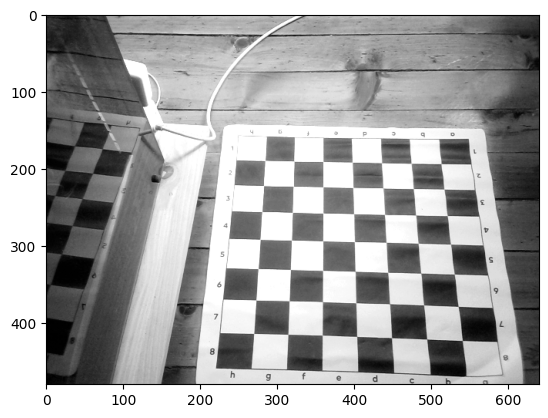

In [27]:
gray_board = cv2.cvtColor(board, cv2.COLOR_BGR2GRAY)
matrix = np.ones(gray_board.shape, dtype=np.uint8) * 1.7
chess_contrasted = np.uint8(np.clip(gray_board * matrix, 0, 255))
plt.imshow(chess_contrasted, cmap='gray')

In [13]:
thresh = 200

In [28]:
_, gr_board_1 = cv2.threshold(chess_contrasted, thresh, 255, cv2.THRESH_BINARY)

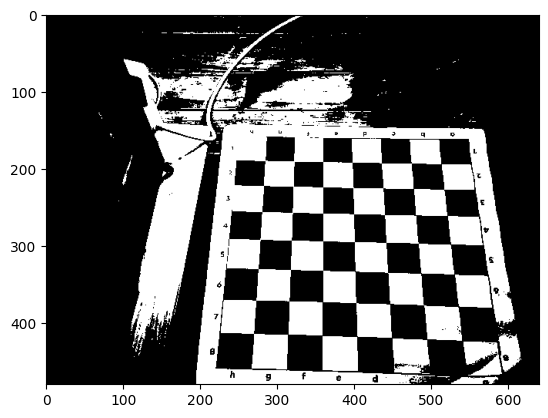

In [29]:
plt.imshow(gr_board_1, cmap='gray')

In [30]:
found, corners = cv2.findChessboardCornersSB(gr_board_1, (7, 7))

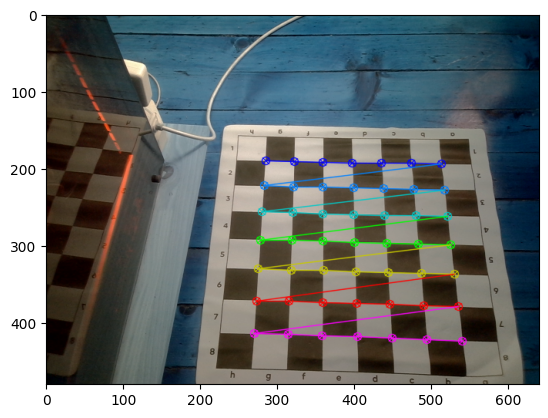

In [31]:
gray = gr_board_1.copy()
chess_corners = board.copy()
if found:
    # Optional: refine corner positions for better accuracy
    criteria = (
        cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER,
        30,
        0.001
    )
    corners = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)

    # Draw the chessboard corners
    cv2.drawChessboardCorners(chess_corners, (7, 7), corners, found)
    plt.imshow(chess_corners)

In [33]:
corners = corners.reshape(7,7, 2)

In [34]:
obj_points = []
for y in range(7):
    for x in range(7):
        obj_points.append([x + 1, y + 1])  # inner corners

obj_points = np.array(obj_points, dtype=np.float32)
img_points = corners.reshape(-1, 2).astype(np.float32)


In [35]:
H, _ = cv2.findHomography(obj_points, img_points)


In [36]:
chess_grid = board.copy()

In [37]:
def board_to_image(x, y):
    pt = np.array([[x, y, 1]], dtype=np.float32).T
    img = H @ pt
    img /= img[2]
    return img[:2].ravel()



In [40]:
square_ref = [
            board_to_image(0, 0),
            board_to_image(1, 0),
            board_to_image(1, 1),
            board_to_image(0, 1)
        ]
square_ref = np.array(square_ref, dtype=np.int32)
# plt.imshow(gray[square_ref[:,1].min():square_ref[:,1].max(),
#                 square_ref[:,0].min():square_ref[:,0].max()], cmap='gray')
center = np.mean(square_ref, axis=0).astype(int)
color = gray[center[1]-1:center[1]+1, center[0]-1:center[0]+1]

Square is white


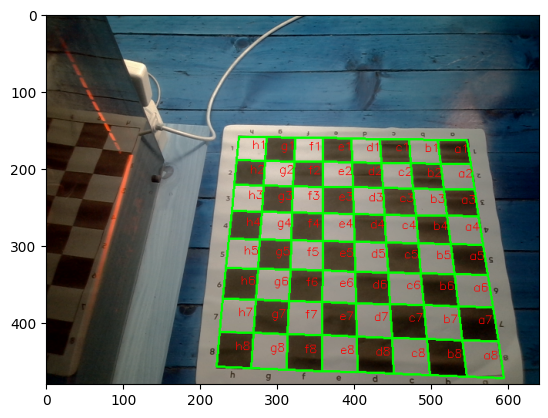

In [ ]:
SQUARE_SIZE = 55

squares = {}
files = "abcdefgh"
rows = range(1, 9)
if np.mean(color) > 127:
    print("Square is white")
    files = files[::-1]
for rank in range(8):
    for file in range(8):
        name = f"{files[file]}{rows[rank]}"
        squares[name] = {}
        squares[name]['view_position'] = [
            board_to_image(file, rank),
            board_to_image(file+1, rank),
            board_to_image(file+1, rank+1),
            board_to_image(file, rank+1)
        ]

        world_x = (ord('d') - ord(files[file])) * SQUARE_SIZE + SQUARE_SIZE / 2
        world_y = (8 - rows[rank]) * SQUARE_SIZE + SQUARE_SIZE / 2
        squares[name]['world_position'] = [world_x, world_y]

        cv2.polylines(chess_grid,
                      [np.int32(squares[name]['view_position'])],
                      True,
                      (0, 255, 0),
                      2)
        pt = np.array(squares[name]['view_position'])[3].astype(int) 
        cv2.putText(chess_grid, name, tuple(pt), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
plt.imshow(chess_grid)

In [55]:
print(squares['d8']['view_position'])

[array([403.70496561, 418.51166639]), array([449.04076781, 420.09021064]), array([451.78717994, 466.64212218]), array([404.95688619, 464.8406657 ])]


In [56]:
print(squares['f4']['world_position'])

[-82.5, 247.5]
